In [1]:
!pip install pandas openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd


path = r"H:\PYTHON\etapa3\atividade 4 - 1 ponto\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

In [3]:
df_censo = pd.read_excel(path, header=2).dropna(subset=["UF"])

In [4]:
col_2010 = "População 2010 (Alterações de Limites até 2022)1"
col_2022 = "População Censo 2022"

df_censo.head()

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0


In [5]:
df_uf = (
    df_censo.groupby("UF")[[col_2010, col_2022]]
    .sum()
    .reset_index()
)

df_uf.head()

,UF,População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,AC,733559.0,830018.0
1,AL,3120887.0,3127683.0
2,AM,3483985.0,3941613.0
3,AP,669526.0,733759.0
4,BA,14017071.0,14141626.0


In [6]:
df_uf["crescimento"] = df_uf[col_2022] - df_uf[col_2010]
df_uf = df_uf.sort_values(by="crescimento", ascending=False)

df_uf.head(10)

,UF,População 2010 (Alterações de Limites até 2022)1,População Censo 2022,crescimento
27,SP,41262199.0,44411238.0,3149039.0
25,SC,6248436.0,7610361.0,1361925.0
9,GO,6001789.0,7056495.0,1054706.0
19,PR,10444526.0,11444380.0,999854.0
11,MG,19597330.0,20539989.0,942659.0
13,MT,3035122.0,3658649.0,623527.0
15,PA,7581051.0,8120131.0,539080.0
2,AM,3483985.0,3941613.0,457628.0
5,CE,8451644.0,8794957.0,343313.0
7,ES,3514952.0,3833712.0,318760.0


In [7]:
df_uf.to_csv("populacao_agregada_uf.csv", sep=";", index=False)

In [8]:
df_censo = df_censo.rename(columns={"NOME DO MUNICÍPIO": "Nome do Município"})
df_municipios = df_censo[["UF", "Nome do Município", col_2010, col_2022]].copy()
df_municipios.head()

,UF,Nome do Município,População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,RO,Alta Floresta D'Oeste,24392.0,21494.0
1,RO,Ariquemes,90353.0,96833.0
2,RO,Cabixi,6313.0,5351.0
3,RO,Cacoal,78574.0,86887.0
4,RO,Cerejeiras,17029.0,15890.0


In [9]:
df_municipios["Crescimento"] = df_municipios[col_2022] - df_municipios[col_2010]

df_municipios = df_municipios.sort_values(by="Crescimento", ascending=False)

df_municipios.head(10)

,UF,Nome do Município,População 2010 (Alterações de Limites até 2022)1,População Censo 2022,Crescimento
111,AM,Manaus,1802014.0,2063689.0,261675.0
5569,DF,Brasília,2572159.0,2817381.0,245222.0
3829,SP,São Paulo,11253503.0,11451999.0,198496.0
3848,SP,Sorocaba,586816.0,723682.0,136866.0
5417,GO,Goiânia,1301912.0,1437366.0,135454.0
138,RR,Boa Vista,284313.0,413486.0,129173.0
4398,SC,Florianópolis,421240.0,537211.0,115971.0
240,PA,Parauapebas,153908.0,267836.0,113928.0
5122,MS,Campo Grande,786774.0,898100.0,111326.0
1337,PB,João Pessoa,723515.0,833932.0,110417.0


In [10]:
df_municipios.to_csv("populacao_municipios.csv", sep=";", index=False)

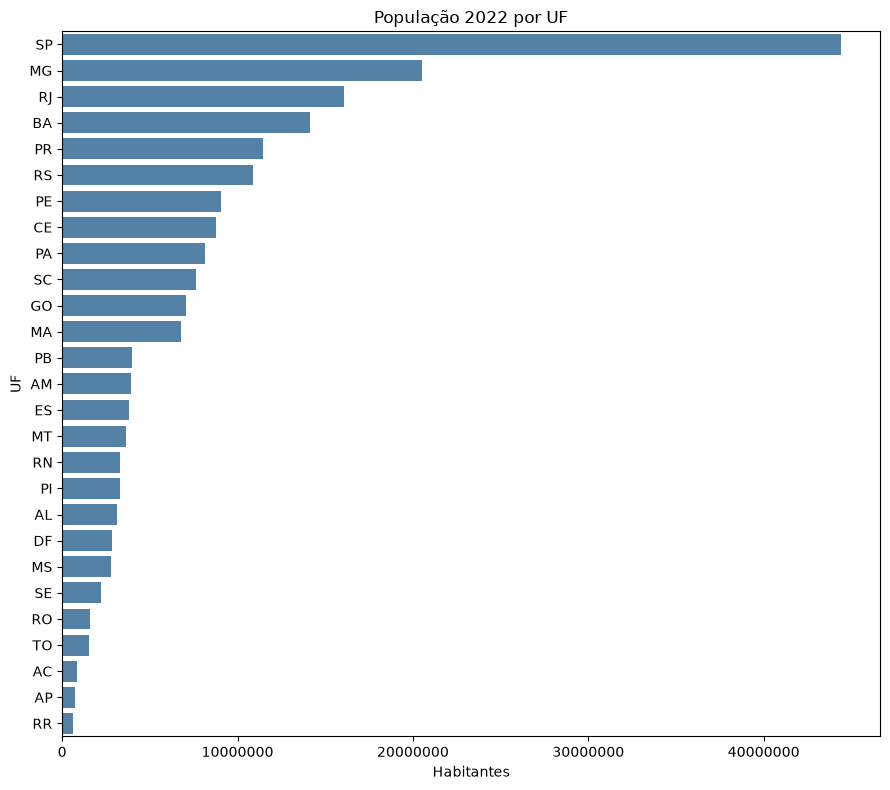

In [13]:
df_uf_limpo = df_uf_ordenado[df_uf_ordenado["UF"].str.len() == 2]

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=df_uf_limpo, y="UF", x=col_2022, ax=ax, color="steelblue")

ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
ax.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()